In [28]:
import pandas as pd 
import numpy as np 
import sys
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[2]
sys.path.insert(0, str(REPO_ROOT / "code"))
import connectivity_based_clustering
from get_mesh_neuron import *

import matplotlib.pyplot as plt
import pickle
from fafbseg import flywire


In [22]:
labial_GRNs_candi = labial_sensory = pickle.load(open('../morphological_clustering/GRN_candidates.pkl','rb'))
labial_GRNs_candi = labial_sensory=  np.setdiff1d(labial_GRNs_candi,[720575940610768738])

In [23]:
mat_g = connectivity_based_clustering.make_adjacency_matrix_GRN_to_2ndtype(labial_GRNs_candi)
Z = connectivity_based_clustering.cluster_GRNs(mat_g)
colors = []

Calc. similarity:   0%|          | 0/50176 [00:00<?, ?it/s]

In [24]:

import distinctipy
from color_utils import *
# colors_wanted = distinctipy.get_colors(20)
# colors_wanted = [rgb_to_hex(x) for x in colors_wanted][::-1]
colors_wanted = ['#0a7f25', '#00ff00','#ff00ff', '#7fbf7f', '#007fff', '#B2C6D5','#364E68','#b3ff47','#ac0902', '#ff7f00', '#610c9f'][::-1]

Calc. similarity:   0%|          | 0/50176 [00:00<?, ?it/s]

/volume_4/research/seongbong/flywire/yu_desilva_geosmin_release/code/connectivity_based_clustering.py:124: RuntimeWarning: divide by zero encountered in log10
  mat_data = np.log10(mat_g_sorted[:, np.argsort(np.sum(mat_g_arr,axis=0))[::-1][:50]])


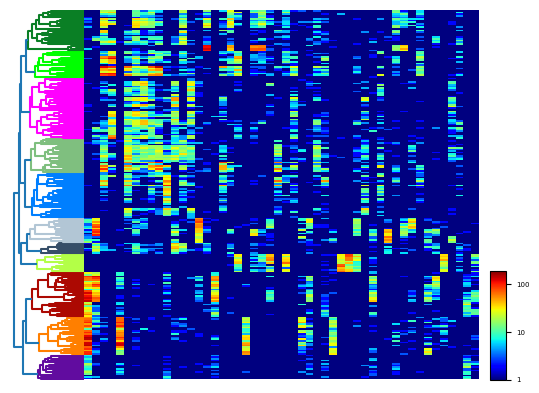

In [25]:
fig,ax = plt.subplots(1,1)
dn = connectivity_based_clustering.draw_dendrogram_with_adjmat(fig,mat_g,labial_GRNs_candi,colors=colors_wanted,threshold=1.86)
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')

cells = np.array(dn['ivl'])
colors = np.array(dn['leaves_color_list'])
type_name = [f"L{list(dict.fromkeys(colors)).index(c)+1}" for c in colors]
cluster_info = pd.DataFrame(columns=['flyid','type'])
cluster_info['flyid'] = cells
cluster_info['type'] = type_name
cluster_info['colors'] = colors


# cluster_info['tastekin'] = [tastekin_fid2type[x] for x in cells]
# cluster_info.to_parquet('/volume_4/research/seongbong/flywire/GRN_project_new/data/labial_cluster_info_v783.parquet')
# cluster_info.to_csv('/volume_4/research/seongbong/flywire/GRN_project_new/data/labial_cluster_info_v783.csv')

Calc. similarity:   0%|          | 0/50176 [00:00<?, ?it/s]

/volume_4/research/seongbong/flywire/yu_desilva_geosmin_release/code/connectivity_based_clustering.py:208: RuntimeWarning: divide by zero encountered in log10
  mat_data = np.log10(mat_g_arr[idx, :][:, top_cols].T)


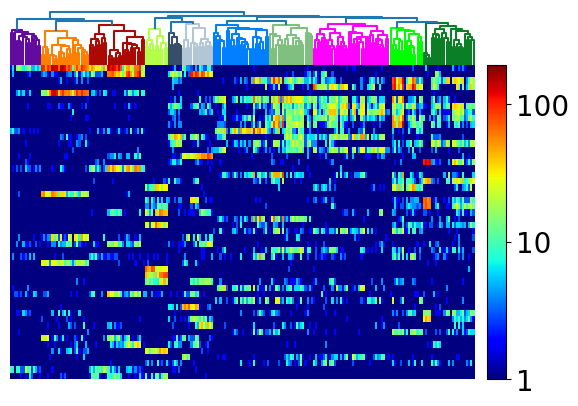

In [27]:
fig,ax = plt.subplots(1,1)
dn = connectivity_based_clustering.draw_dendrogram_with_adjmat_vertical(fig,mat_g,labial_GRNs_candi,colors=colors_wanted,threshold=1.86)
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')

cells = np.array(dn['ivl'])
colors = np.array(dn['leaves_color_list'])
type_name = [f"L{list(dict.fromkeys(colors)).index(c)+1}" for c in colors]
cluster_info = pd.DataFrame(columns=['flyid','type'])
cluster_info['flyid'] = cells
cluster_info['type'] = type_name
cluster_info['colors'] = colors

# plt.savefig('labial_clustering_result.svg',bbox_inches='tight')
